In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [32]:
df = pd.read_csv("poblacion-por-alcaldia-cdmx.csv")
df

,Año,Alcaldia,Población total
0,1990,Álvaro Obregón,"640,749"
1,1990,Azcapotzalco,"474,688"
2,1990,Benito Juárez,"407,811"
3,1990,Coyoacán,"640,066"
4,1990,Cuajimalpa de Morelos,"114,385"
...,...,...,...
114,2020,Tláhuac,"392,313"
115,2020,Tlalpan,"699,928"
116,2020,Venustiano Carranza,"443,704"
117,2020,Xochimilco,"442,178"


In [33]:
# ----- Conocer el tamaño del Data Frame -----
print(f"El Data Frame tiene {df.shape[0]} filas")
print(f"El Data Frame tiene {df.shape[1]} columnas")

El Data Frame tiene 119 filas
El Data Frame tiene 3 columnas


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Año              119 non-null    int64 
 1   Alcaldia         119 non-null    object
 2   Población total  119 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.9+ KB


In [35]:
# Ver todas las alcaldías de la CDMX (están todas)
lista_de_alcaldias = list(df["Alcaldia"].unique())
numero_de_alcaldias = len(df["Alcaldia"].value_counts()) # Son 16 alcaldías pero hay una llamada "CDMX", por lo que sube a 17 alcadías
lista_de_alcaldias

['Álvaro Obregón',
 'Azcapotzalco',
 'Benito Juárez',
 'Coyoacán',
 'Cuajimalpa de Morelos',
 'Cuauhtémoc',
 'Gustavo A. Madero',
 'Iztacalco',
 'Iztapalapa',
 'La Magdalena Contreras',
 'Miguel Hidalgo',
 'Milpa Alta',
 'Tláhuac',
 'Tlalpan',
 'Venustiano Carranza',
 'Xochimilco',
 'CDMX']

In [36]:
# Ver los años que tiene el Data Frame
df["Año"].unique() # Los años del Data Frame van de 5 años en 5 años. Es decir cada lustro se hacia la medición de la población.

array([1990, 1995, 2000, 2005, 2010, 2015, 2020])

In [37]:
# Quitamos de la columna "Alcaldia" a "CDMX" para que la suma se la población sea exacta
df_solo_alcaldias = df[df["Alcaldia"] != "CDMX"]

# Vemos la cantidad de alcaldías que son ahora, ya que quitamos "CDMX"
len(df_solo_alcaldias["Alcaldia"].value_counts()) # Está bien el número (16)

# Convertimos la columna "Población total" a int (ya que está en str)
df_solo_alcaldias["Población total"] = (df_solo_alcaldias["Población total"].str.replace(",", "", regex=False).astype(int)) # Quitamos las comas y convertimos a int

/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_6006/958835878.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_solo_alcaldias["Población total"] = (df_solo_alcaldias["Población total"].str.replace(",", "", regex=False).astype(int)) # Quitamos las comas y convertimos a int


In [38]:
# ----- Cantidad total de la población en el último año (para ver la suma total) -----

# Filtramos el Data Frame por el año 2020
poblacion_2020 = df_solo_alcaldias[df_solo_alcaldias["Año"] == 2020]

# Agrupamos la población del 2020 por alcaldía
poblacion_2020.groupby("Alcaldia")["Población total"].sum()
total_poblacion_cdmx = poblacion_2020["Población total"].sum()

# Mostramos en pantalla
print(f"La cantidad total de personas que hay en la CDMX es de {total_poblacion_cdmx:,.2f}") # 9,209,944 personas

La cantidad total de personas que hay en la CDMX es de 9,209,944.00


/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_6006/1645119267.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=poblacion_total_por_alcaldia.index,


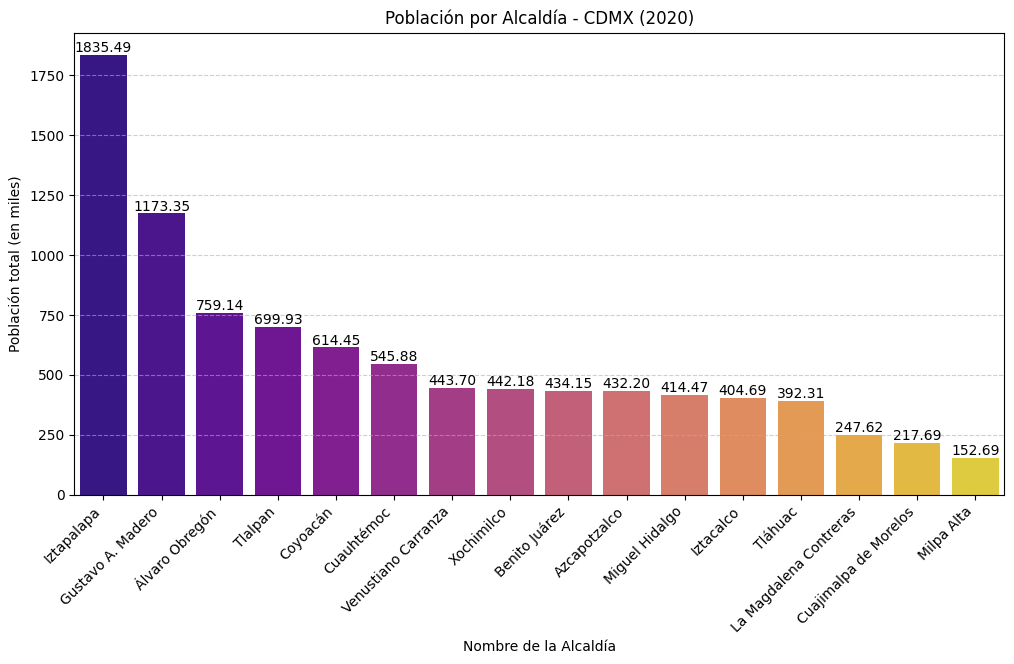

In [39]:
# ----- Graficamos la población por alcaldía -----
poblacion_total_por_alcaldia = poblacion_2020.groupby("Alcaldia")["Población total"].sum().sort_values(ascending=False)
# Graficamos
plt.figure(figsize=(12,6))
plt.title("Población por Alcaldía - CDMX (2020)")
barras = sns.barplot(x=poblacion_total_por_alcaldia.index,
                     y=poblacion_total_por_alcaldia.values / 1000,
                     palette="plasma")
# Agregamos el número de habitantes en cada barra
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='%.2f')
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.xlabel("Nombre de la Alcaldía")
plt.ylabel("Población total (en miles)")
plt.xticks(rotation=45,
           ha="right")
plt.show()

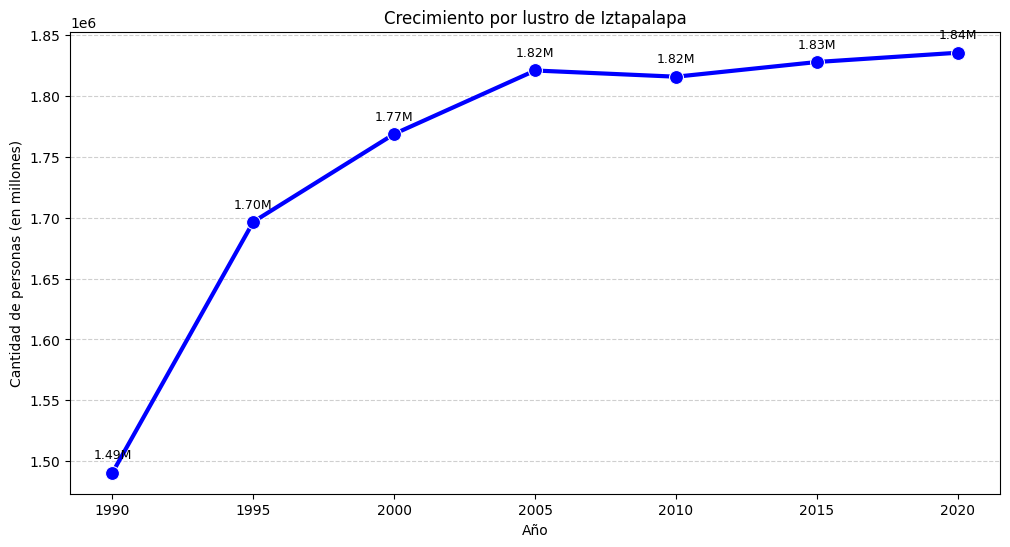

In [40]:
# ----- Grafica del crecimiento por lustro de Iztapalapa -----

# Creamos un Data Frame solo de Iztapalapa
df_iztapalapa = df_solo_alcaldias[df_solo_alcaldias["Alcaldia"] == "Iztapalapa"]

# Agrupamos a Iztapalapa por año y población total
crecimiento_iztapalapa = df_iztapalapa.groupby("Año")["Población total"].sum()

# Graficamos
plt.figure(figsize=(12,6))
plt.title("Crecimiento por lustro de Iztapalapa")
sns.lineplot(x=crecimiento_iztapalapa.index,
             y=crecimiento_iztapalapa.values,
             color="blue",
             marker="o",
             linewidth=3,
             markersize=10)

# Añadir valores en cada punto (data labels)
for i, (year, pop) in enumerate(zip(crecimiento_iztapalapa.index, crecimiento_iztapalapa.values)):
    plt.annotate(f'{pop/1e6:.2f}M', 
                 (year, pop), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center',
                 fontsize=9)

plt.xlabel("Año")
plt.ylabel("Cantidad de personas (en millones)")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()


La cantidad de habitates que tendrá Iztapalapa en el 2025 será de 1,942,914 millones de habitantes


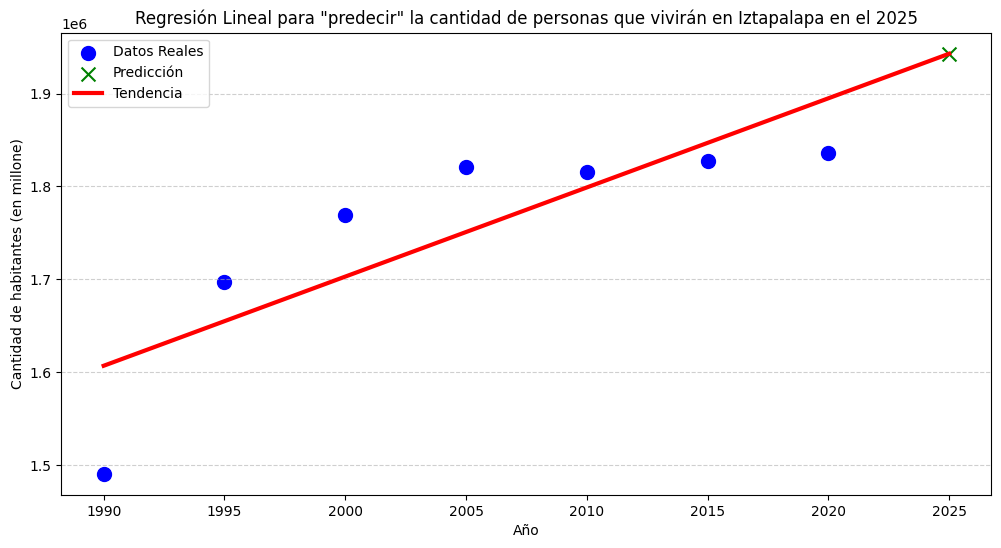

In [41]:
# ----- Regresión Lineal para "predecir" la cantidad de personas que vivirán en Iztapalapa en el 2025 -----
# Como el 2025 fué hace 1 año esta Regresión Lineal sirve para ver si la misma se acercó o acertó la cantidad real

# Creamos los valores X, y
X = np.linspace(1990, 2020, 7).reshape(-1 ,1)
y = crecimiento_iztapalapa.values

# Creamos y entrenamos el modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Hacemos el array del 2025 y hacemos la predicción
año_2025_Iztapalapa = np.array([2025]).reshape(-1, 1)
predic_2025_Iztapalapa = modelo.predict(año_2025_Iztapalapa)

# Mostramos en pantalla
print(f"La cantidad de habitates que tendrá Iztapalapa en el 2025 será de {predic_2025_Iztapalapa[0]:,.0f} millones de habitantes")

# Graficamos
plt.figure(figsize=(12,6))
plt.title('Regresión Lineal para "predecir" la cantidad de personas que vivirán en Iztapalapa en el 2025')
# Graficamos los datos reales (puntos azules)
plt.scatter(X,
            y,
            color="blue",
            marker="o",
            s=100,
            label="Datos Reales")
# Graficamos la predicción
plt.scatter(año_2025_Iztapalapa,
            predic_2025_Iztapalapa,
            color="green",
            marker="x",
            s=100,
            label="Predicción")

# Hacemos la línea roja
eje_X = np.linspace(1990, 2025, 8).reshape(-1, 1)
eje_y = modelo.predict(eje_X)
plt.plot(eje_X,
         eje_y,
         color="red",
         linewidth=3,
         label="Tendencia")

plt.xlabel("Año")
plt.ylabel("Cantidad de habitantes (en millone)")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.legend()
plt.show()

### ⚠️ Análisis Crítico: ¿Por qué la regresión lineal de arriba ⬆️ (habitantes de Iztapalapa para el 2025) está mal?  
La Regresión Lineal generó una predicción erronea, ya que la cantidad de habitantes de la alcaldía Iztapalapa en el 2025 según cifras del **INEGI** fue de aproximadamente 1,815,786 personas, y el modelo predijo _1,942,914 millones de habitantes_ lo que indica que se pasó por 127,128 habitantes.  

Esto se debe a que los datos con los que entrenamos al modelo no son suficientes, debido a que los datos se recavaron cada cinco años (lustro) por lo que de la cantidad de intervalos de años es la mima cantidad de datos con lo que entrenaremos al modelo y si los intervalos son pocos, los datos serán pocos y deficientes lo que hace que el modelo tienda a fallas y a predecir valores fuera de lugar. Esto se puede solucionar sacando la cantidad de población aproximada por cada año (sin intervalos) o si es por intervalos tratar que la cantidad de intervalos sea mayor a la cantidad de intervalos que hay originalmente, por ejemplo:  
* 1990 - 2020 hay 7 intervalos de 5 años cada uno.

* Una propuesta puede ser de 1990 - 2020 con 16 intervalos de 2 años cada uno, lo cuál beneficiaria al modelo ya que serian mas datos para hacer mas extacta la predicción del modelo.

Cantidad de habitantes para el 2025: 1,940,933.67


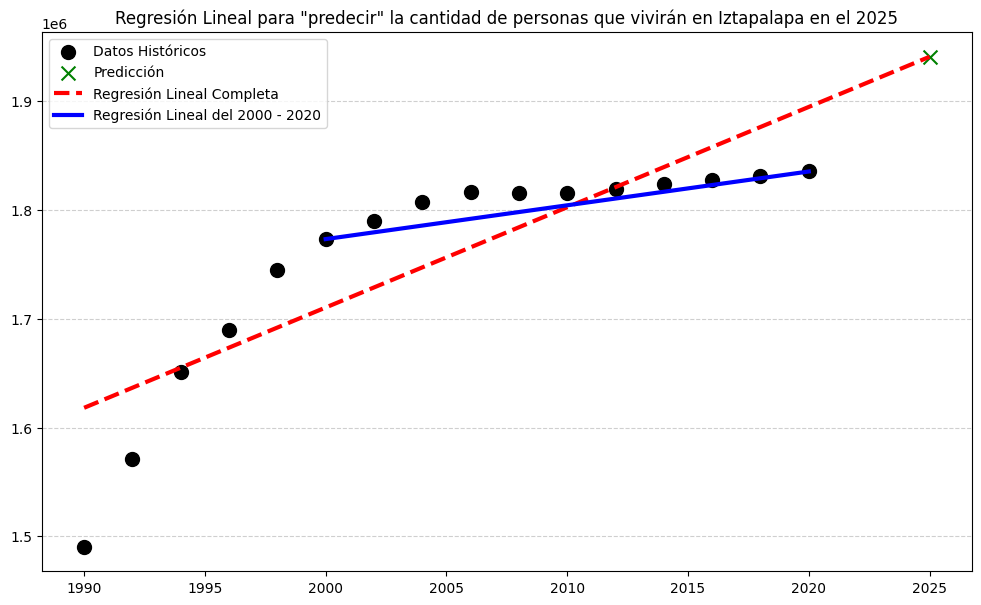

In [56]:
# ----- Regresión Lineal para "predecir" la cantidad de personas que vivirán en Iztapalapa en el 2025 REMASTERIZADA-----

# Creamos un array de la cantidad de habitantes de Iztapalapa del 1990 - 2020 por cada dos años (16 intervalos)
y_remasted = np.array([1490499, 1570814, 1651129, 1689455, 1745380, 1773343, 1790240, 1807137, 
                       1816400, 1815998, 1815786, 1819819, 1823852, 1827792, 1831639, 1835486])

# Creamos la variable X
X_remasted = np.linspace(1990, 2020, 16).reshape(-1 ,1)

# Creamos y entrenamos el modelo
modelo_remasted = LinearRegression()
modelo_remasted.fit(X_remasted, y_remasted)

# Creamos el array del año que queremos predecir
año_futuro = np.array([2025]).reshape(-1, 1)

# Hacemos la predicción
predic_remasted = modelo_remasted.predict(año_futuro)

# Mostramos en pantalla
print(f"Cantidad de habitantes para el 2025: {predic_remasted[0]:,.2f}") # Cantidad de habitantes para el 2025: 1,940,933.67

# Graficamos
plt.figure(figsize=(12,7))
plt.title('Regresión Lineal para "predecir" la cantidad de personas que vivirán en Iztapalapa en el 2025')
# Graficamos los puntos azules
plt.scatter(X_remasted,
         y_remasted,
         color="black",
         marker="o",
         s=100,
         label="Datos Históricos")
# Graficamos la predicción
plt.scatter(año_futuro,
            predic_remasted,
            color="green",
            marker="x",
            s=100,
            label="Predicción")
# Graficamos la línea roja
eje_X_remasted = np.linspace(1990,2025,36).reshape(-1, 1)
eje_y_remasted = modelo_remasted.predict(eje_X_remasted)
plt.plot(eje_X_remasted,
         eje_y_remasted,
         color="red",
         linestyle="--",
         linewidth=3,
         label="Regresión Lineal Completa")

# Graficamos la Regresión Lineal del 2000 - 2020
X_new = np.linspace(2000, 2020, 2).reshape(-1, 1)
y_new = np.array([1773343, 1835486])

plt.plot(X_new,
         y_new,
         color="blue",
         linewidth=3,
         label ="Regresión Lineal del 2000 - 2020")

plt.legend()
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()

## 🟡 Análisis Explicativo: ¿Por qué la gráfica de arriba tiene dos líneas (línea roja y azul)?  

La gráfica de arriba tiene dos líneas debido a que:
1. _Línea roja:_ La línea roja es la que simula ser la "regresión lineal", pero en este caso una regresión lineal no sirve y no aplica ya que como se puede ver en los puntos color negro, estos no siguen una línea recta o línea uniforme debido a que la mayoria de las veces los datos de la vida real **no siguen una línea recta**
2. _Línea azul:_ La línea azul a diferencia de la otra línea los puntos color negro parece que se apegan o se acercan mas a la tendencia de esta línea, por lo que se podría decir que "_La línea azul es una mini regresión lineal_" sin embargo como mencioné: estos datos **no se pueden predecir ni graficar con una línea recta**